In [1]:
import gymnasium as gym 
from __future__ import annotations

import random 
import matplotlib.pyplot as plt 
import numpy as np 
import  pandas as pd  
import seaborn as sns 
import torch 
import torch.nn as nn 
from torch.distributions.normal import Normal

In [2]:
class Policy_Network(nn.Module):

    def __init__(self, obs_space_dims , action_space_dims):
        super().__init__()

        hidden_space_1 = 16
        hidden_space_2 = 32 

        self.shared_net = nn.Sequential(
            nn.Linear(obs_space_dims,hidden_space_1),
            nn.Tanh(),
            nn.Linear(hidden_space_1,hidden_space_2),
            nn.Tanh(),
        )

        self.policy_mean_net = nn.Sequential(
            nn.Linear(hidden_space_2,action_space_dims)
        )

        self.policy_stddev_net = nn.Sequential(
            nn.Linear(hidden_space_2,action_space_dims)
        )

    def forward(self,x:torch.tensor)-> tuple[torch.tensor,torch.tensor]:

        shared_features = self.shared_net(x.float())
        action_means = self.policy_mean_net(shared_features)
        action_stddevs = torch.log(1 + torch.exp(self.policy_stddev_net(shared_features)))
        return action_means,action_stddevs


        

In [4]:
class REINFORCE:
    def __init__(self, obs_space_dims : int , action_space_dims : int):

        self.learning_rate = 0.0001
        self.gamma = 0.99
        self.eps = 1e-6

        self.probs = []
        self.rewards = []

        self.net = Policy_Network(obs_space_dims,action_space_dims)
        self.optimizer = torch.optim.Adam(self.net.parameters(), lr = self.learning_rate)

    def sample_action(self,state:np.ndarray) -> float:
        state = torch.tensor(np.array([state]))
        action_means , action_stddevs = self.net(state)

        distrb = Normal(action_means[0]+self.eps,action_stddevs[0]+self.eps)
        action = distrb.sample()
        prob = distrb.log_prob(action)
        action = action.numpy()
        self.probs.append(prob)
        return action
    
    def update(self):
        running_g = 0
        gs = []

        for R in self.rewards[::-1]:
            running_g  = R + self.gamma *running_g
            gs.insert(0,running_g)

        deltas = torch.tensor(gs)

        log_probs = torch.stack(self.probs).squeeze()

        loss = -torch.sum(log_probs*deltas)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        self.probs = []
        self.rewards = []       

In [10]:
env = gym.make("InvertedPendulum-v4")
# env.action_space.shape[0]
env.observation_space.shape[0]

4

In [5]:
env = gym.make("InvertedPendulum-v4")
wrapped_env = gym.wrappers.RecordEpisodeStatistics(env,50)

total_num_episodes = int(5e3)
obs_space_dims = env.observation_space.shape[0]
action_space_dims = env.action_space.shape[0]
rewards_over_seeds = []

for seed in [1,2,3,5,8]:

    torch.manual_seed(seed)
    random.seed(seed)
    np.random.seed(seed)

    agent = REINFORCE(obs_space_dims,action_space_dims)
    reward_over_episodes = []

    for episode in range(total_num_episodes):

        obs,info = wrapped_env.reset(seed=seed)

        done = False
        while not done:
            action = agent.sample_action(obs)

            obs , reward ,terminated , truncated ,info = wrapped_env.step(action) 
            agent.rewards.append(reward)

            done = terminated or truncated

        reward_over_episodes.append(wrapped_env.return_queue[-1])
        agent.update()

        if episode % 1000 == 0:
            avg_reward = int(np.mean(wrapped_env.return_queue))
            print("Episode : ",episode, "Average Reward :",avg_reward)

    rewards_over_seeds.append(reward_over_episodes)
    


c:\Anaconda\envs\RL\Lib\site-packages\gymnasium\envs\registration.py:512: DeprecationWarning: WARN: The environment InvertedPendulum-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(


Episode :  0 Average Reward : 8
Episode :  1000 Average Reward : 43
Episode :  2000 Average Reward : 90
Episode :  3000 Average Reward : 122
Episode :  4000 Average Reward : 153
Episode :  0 Average Reward : 233
Episode :  1000 Average Reward : 20
Episode :  2000 Average Reward : 67
Episode :  3000 Average Reward : 132
Episode :  4000 Average Reward : 157
Episode :  0 Average Reward : 206
Episode :  1000 Average Reward : 15
Episode :  2000 Average Reward : 39
Episode :  3000 Average Reward : 265
Episode :  4000 Average Reward : 855
Episode :  0 Average Reward : 859
Episode :  1000 Average Reward : 15
Episode :  2000 Average Reward : 38
Episode :  3000 Average Reward : 121
Episode :  4000 Average Reward : 242
Episode :  0 Average Reward : 746
Episode :  1000 Average Reward : 18
Episode :  2000 Average Reward : 60
Episode :  3000 Average Reward : 130
Episode :  4000 Average Reward : 258


In [8]:
torch.save(agent.net.state_dict(), "agent_weights")

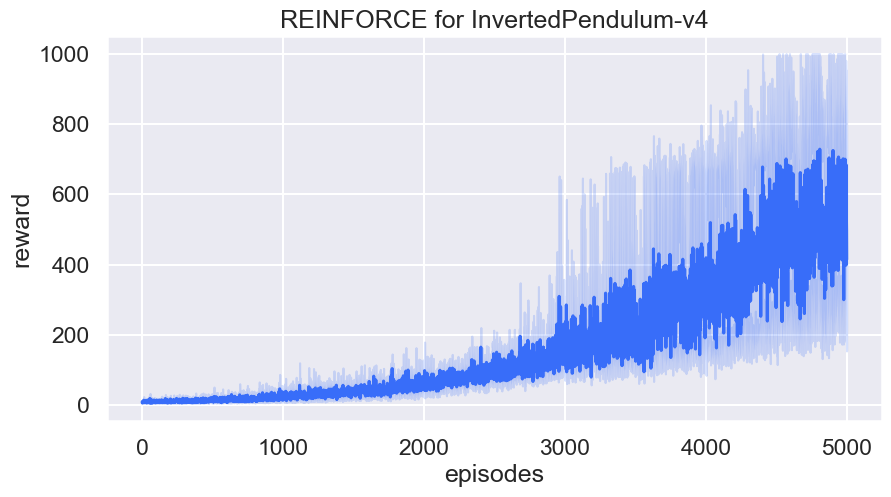

In [ ]:
plt.rcParams["figure.figsize"] = (10,5)
df1 = pd.DataFrame(rewards_over_seeds).melt()
df1.rename(columns={"variable": "episodes", "value": "reward"}, inplace=True)
sns.set(style="darkgrid", context="talk", palette="rainbow")
sns.lineplot(x="episodes", y="reward", data=df1).set(
    title="REINFORCE for InvertedPendulum-v4"
)
plt.show()

In [5]:

# Recreate environment with rendering
env = gym.make("InvertedPendulum-v4", render_mode="human")

obs_space_dims = env.observation_space.shape[0]
action_space_dims = env.action_space.shape[0]

# Rebuild the policy network (same architecture)
agent = REINFORCE(obs_space_dims, action_space_dims)

# Load trained weights
agent.net.load_state_dict(torch.load("agent_weights"))
agent.net.eval()  # set to evaluation mode

num_test_episodes = 10

for episode in range(num_test_episodes):
    obs, info = env.reset()
    done = False
    total_reward = 0

    while not done:
        # Convert observation
        state = torch.tensor(np.array([obs]))

        # Forward pass (no gradient)
        with torch.no_grad():
            action_means, action_stddevs = agent.net(state)

        # Use mean action (deterministic policy for testing)
        action = action_means[0].numpy()

        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        total_reward += reward

    print(f"Test Episode {episode+1}: Reward = {total_reward}")

env.close()

c:\Anaconda\envs\RL\Lib\site-packages\gymnasium\envs\registration.py:512: DeprecationWarning: WARN: The environment InvertedPendulum-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(
C:\Users\User\AppData\Local\Temp\ipykernel_15940\1268878479.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=Tr

Test Episode 1: Reward = 1000.0
Test Episode 2: Reward = 1000.0
Test Episode 3: Reward = 1000.0
Test Episode 4: Reward = 1000.0
Test Episode 5: Reward = 1000.0
Test Episode 6: Reward = 1000.0
Test Episode 7: Reward = 1000.0
Test Episode 8: Reward = 1000.0
Test Episode 9: Reward = 1000.0


c:\Anaconda\envs\RL\Lib\site-packages\glfw\__init__.py:917: GLFWError: (65537) b'The GLFW library is not initialized'
  warnings.warn(message, GLFWError)


Test Episode 10: Reward = 1000.0


In [6]:
env = gym.make("InvertedPendulum-v4",render_mode  = "human")
obs_space_dims = env.observation_space.shape[0]
action_space_dims = env.action_space.shape[0]

test_agent = REINFORCE(obs_space_dims,action_space_dims)

test_agent.net.load_state_dict(torch.load("agent_weights"))
test_agent.net.eval()

for i in range(10):
    done = False
    state , info = env.reset()

    while not done:
        action = test_agent.sample_action(state)
        state, reward, terminated , truncated , info = env.step(action)
        done = terminated or truncated
env.close()



c:\Anaconda\envs\RL\Lib\site-packages\gymnasium\envs\registration.py:512: DeprecationWarning: WARN: The environment InvertedPendulum-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(
C:\Users\User\AppData\Local\Temp\ipykernel_14396\1378185869.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=Tru